# 08a — Reddit EDA: r/Forex · r/investing · r/stocks · r/Economics

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

ROOT    = Path().resolve().parent
RAW_DIR = ROOT / "data" / "raw" / "reddit"

FILES = {
    "Forex"    : RAW_DIR / "forex_raw_20260405_192900.jsonl",
    "investing": RAW_DIR / "investing_raw_20260405_210126.jsonl",
    "stocks"   : RAW_DIR / "stocks_raw_20260405_210126.jsonl",
    "Economics": RAW_DIR / "economics_raw_20260405_210126.jsonl",
}

for label, path in FILES.items():
    size = f"{path.stat().st_size / 1_048_576:.0f} MB"
    print(f"  r/{label:<12}  {size:<10}  {path.name}")

  r/Forex         363 MB      forex_raw_20260405_192900.jsonl
  r/investing     549 MB      investing_raw_20260405_210126.jsonl
  r/stocks        738 MB      stocks_raw_20260405_210126.jsonl
  r/Economics     260 MB      economics_raw_20260405_210126.jsonl


In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

frames = {}
for label, path in FILES.items():
    print(f"Loading r/{label}...", end=" ", flush=True)
    df = load_jsonl(path)
    frames[label] = df
    print(f"{len(df):,} posts  |  {df.memory_usage(deep=True).sum() / 1_048_576:.0f} MB")

df_all = pd.concat(frames.values(), ignore_index=True)

df_all["created_dt"]  = pd.to_datetime(df_all["created_utc"], unit="s", utc=True)
df_all["year"]        = df_all["created_dt"].dt.year
df_all["hour"]        = df_all["created_dt"].dt.hour
df_all["weekday"]     = df_all["created_dt"].dt.day_name()
df_all["text_length"] = (df_all["title"].fillna("") + " " + df_all["selftext"].fillna("")).str.len()
df_all["is_deleted"]  = df_all["removed_by_category"].isin(["deleted", "moderator", "author"])
df_all["has_body"]    = df_all["selftext"].fillna("").str.strip().apply(
    lambda x: x not in ("", "[deleted]", "[removed]")
)

def classify_type(row):
    if row.get("is_video"):               return "video"
    if row.get("is_gallery"):             return "gallery"
    if row.get("is_self"):                return "text"
    if row.get("is_reddit_media_domain"): return "image"
    return "external"

df_all["post_type"] = df_all.apply(classify_type, axis=1)

print(f"\nTotal: {len(df_all):,} posts | {df_all.memory_usage(deep=True).sum()/1_048_576:.0f} MB in RAM")
print(f"Columns: {df_all.shape[1]}")

Loading r/Forex... 

112,809 posts  |  452 MB
Loading r/investing... 

203,178 posts  |  780 MB
Loading r/stocks... 

257,669 posts  |  1045 MB
Loading r/Economics... 

75,916 posts  |  298 MB



Total: 649,572 posts | 2719 MB in RAM
Columns: 135


## 1. Dataset Overview

In [3]:
summary = df_all.groupby("subreddit").agg(
    posts          = ("id",           "count"),
    unique_authors = ("author",       "nunique"),
    date_min       = ("created_dt",   "min"),
    date_max       = ("created_dt",   "max"),
    deleted_pct    = ("is_deleted",   lambda x: f"{x.mean()*100:.1f}%"),
    median_score   = ("score",        "median"),
    median_comments= ("num_comments", "median"),
).reset_index()
summary["date_min"] = summary["date_min"].dt.strftime("%Y-%m-%d")
summary["date_max"] = summary["date_max"].dt.strftime("%Y-%m-%d")
print(summary.to_string(index=False))

subreddit  posts  unique_authors   date_min   date_max deleted_pct  median_score  median_comments
Economics  75916           16983 2021-01-01 2025-12-31       30.0%           1.0              1.0
    Forex 112809           44797 2021-01-01 2025-12-31       30.0%           1.0              1.0
investing 203178          111058 2021-01-01 2025-12-31       66.1%           1.0              1.0
   stocks 257669          134587 2021-01-01 2025-12-31       67.0%           1.0              0.0


**Observations:**
- **649,572 posts** total across 4 subreddits. r/stocks is largest (257k), r/Economics smallest (75k).
- All 4 files cover the full 2021–2025 range with no gaps.
- **Critical quality split:** r/Economics and r/Forex have ~30% deleted posts. r/investing and r/stocks are catastrophically worse — **66–67% of posts are deleted/removed**. Two-thirds of investing and stocks content is gone.
- Median score = 1 and median comments = 0–1 across all subreddits — the vast majority of posts get virtually zero traction. Engagement is extremely skewed; signal will come from the top tail, not the average post.

## 2. Data Quality — Deletion Breakdown

In [4]:
del_breakdown = (
    df_all.groupby(["subreddit", "removed_by_category"])
    .size()
    .unstack(fill_value=0)
)
del_breakdown["TOTAL"] = del_breakdown.sum(axis=1)
print(del_breakdown.to_string())

removed_by_category  author  automod_filtered  content_takedown  copyright_takedown  deleted  moderator  reddit   TOTAL
subreddit                                                                                                              
Economics                 2                 0                 9                   1     5581      17222   15558   38373
Forex                     0                 0                14                   3     8277      25587   21845   55726
investing                 3                 0                23                   0    23252     111019   13047  147344
stocks                    2                 1                29                   0    30566     142063    9298  181959


In [5]:
text_quality = df_all.groupby("subreddit").agg(
    total    = ("id",       "count"),
    has_body = ("has_body", "sum"),
).assign(body_pct=lambda d: (d["has_body"] / d["total"] * 100).round(1))
print(text_quality.to_string())

            total  has_body  body_pct
subreddit                            
Economics   75916      1081       1.4
Forex      112809     42803      37.9
investing  203178     52359      25.8
stocks     257669     70883      27.5


**Observations:**
- The deletion is dominated by **moderator removals** (not user deletions) — especially r/investing (111k mod-removed) and r/stocks (142k mod-removed). These subreddits enforce strict posting rules aggressively.
- **Body text availability is extremely low.** r/Economics has only **1.4%** of posts with a body — it is essentially a headline-only community (link posts). r/Forex has the most body text at 37.9%, still meaning 62% of posts are title-only. For NLP signal extraction, r/Forex is the richest; r/Economics is nearly useless for body-text-based analysis.
- The `reddit` category (15k–21k posts) represents platform-level removals — likely spam or TOS violations, not community moderation.

## 3. Post Type Distribution

post_type  gallery  video
subreddit                
Economics     99.4    0.6
Forex         98.3    1.7
investing    100.0    0.0
stocks       100.0    0.0


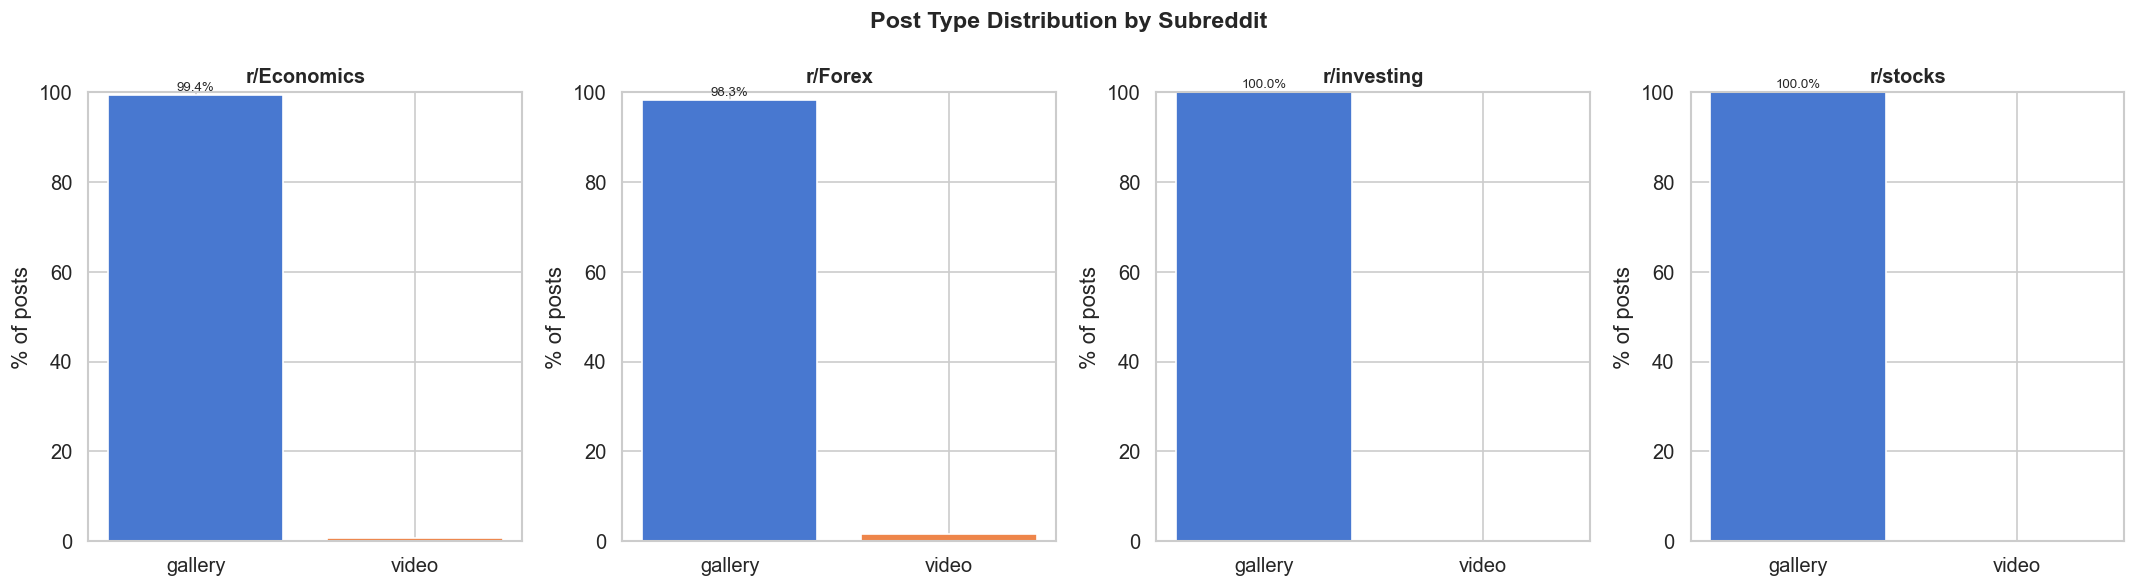

In [6]:
type_counts = df_all.groupby(["subreddit", "post_type"]).size().unstack(fill_value=0)
type_pct    = type_counts.div(type_counts.sum(axis=1), axis=0) * 100
print(type_pct.round(1).to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = sns.color_palette("muted", n_colors=len(type_pct.columns))
for ax, (sr, row) in zip(axes, type_pct.iterrows()):
    row_s = row.sort_values(ascending=False)
    bars  = ax.bar(row_s.index, row_s.values, color=colors[:len(row_s)])
    ax.set_title(f"r/{sr}", fontsize=12, fontweight="bold")
    ax.set_ylabel("% of posts"); ax.set_ylim(0, 100)
    for bar in bars:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha="center", fontsize=8)
fig.suptitle("Post Type Distribution by Subreddit", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

post_type  external  gallery  image   text  video
subreddit                                        
Economics      96.5      0.2    1.5    1.2    0.6
Forex           3.8      8.8   23.1   62.6    1.7
investing       0.0      0.0    0.0  100.0    0.0
stocks          0.0      0.0    0.0  100.0    0.0


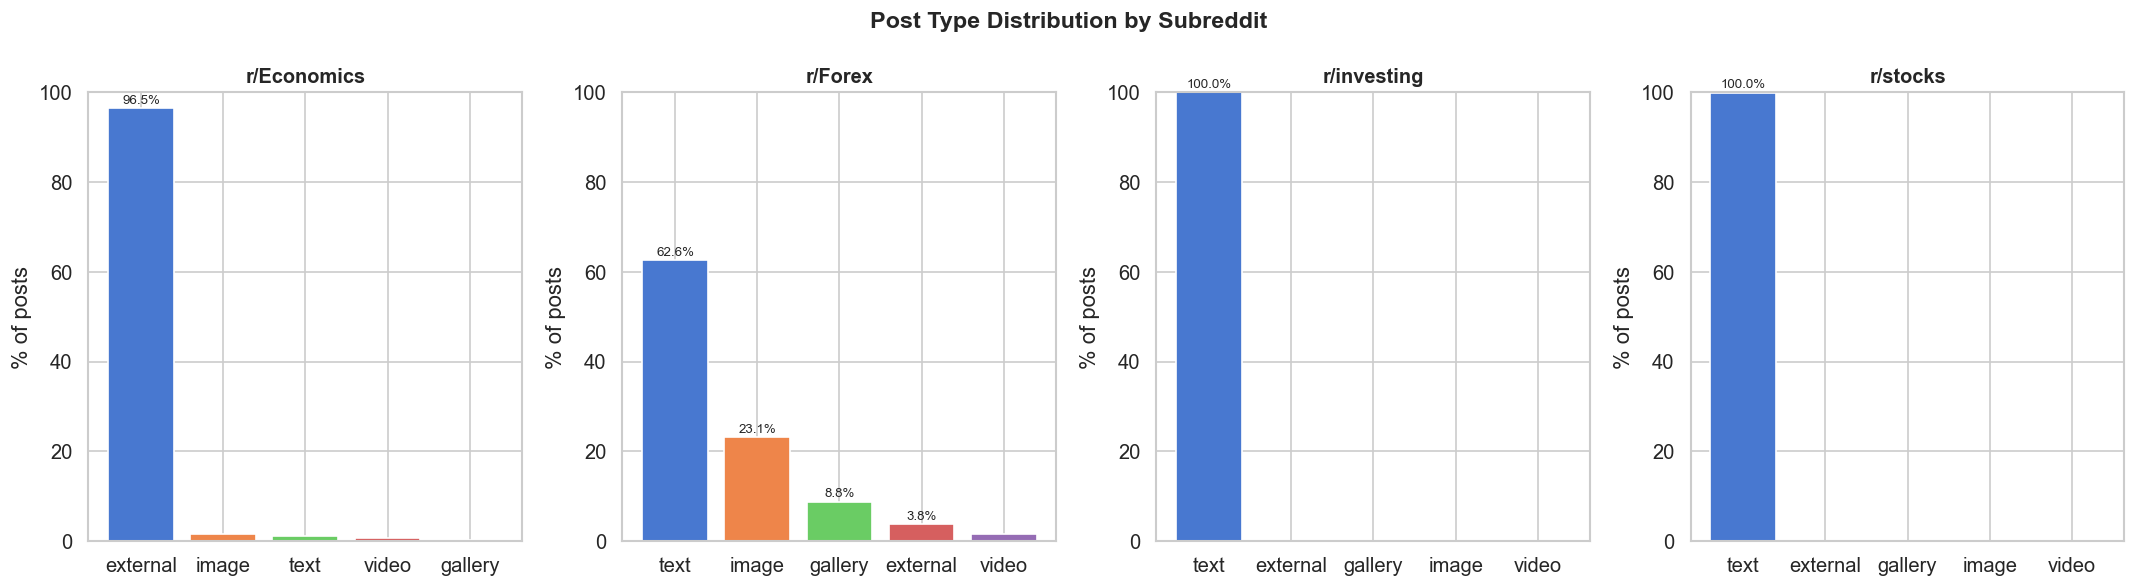

In [7]:
# Fix: NaN fields are truthy in Python — use vectorized boolean comparison instead
df_all["post_type"] = "external"
df_all.loc[df_all["is_reddit_media_domain"] == True, "post_type"] = "image"
df_all.loc[df_all["is_self"]               == True, "post_type"] = "text"
df_all.loc[df_all["is_gallery"]            == True, "post_type"] = "gallery"
df_all.loc[df_all["is_video"]              == True, "post_type"] = "video"

type_counts = df_all.groupby(["subreddit", "post_type"]).size().unstack(fill_value=0)
type_pct    = type_counts.div(type_counts.sum(axis=1), axis=0) * 100
print(type_pct.round(1).to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = sns.color_palette("muted", n_colors=len(type_pct.columns))
for ax, (sr, row) in zip(axes, type_pct.iterrows()):
    row_s = row.sort_values(ascending=False)
    bars  = ax.bar(row_s.index, row_s.values, color=colors[:len(row_s)])
    ax.set_title(f"r/{sr}", fontsize=12, fontweight="bold")
    ax.set_ylabel("% of posts"); ax.set_ylim(0, 100)
    for bar in bars:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h+1, f"{h:.1f}%", ha="center", fontsize=8)
fig.suptitle("Post Type Distribution by Subreddit", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

**Observations:**
- **r/Economics = link aggregator (96.5% external links).** It doesn't generate original discussion — it re-posts news articles and academic papers. Text analysis on body content is pointless here; value comes from *which* articles get shared and how much engagement they attract.
- **r/Forex = mixed and visually rich (62.6% text, 23.1% images, 8.8% galleries, 1.7% video).** Images are almost certainly chart screenshots — traders sharing setups. This is the only subreddit where visual content (chart images) could carry technical analysis signal.
- **r/investing and r/stocks = 100% text (self-posts only).** These communities are configured by mods to allow only self-posts. All discussion is original written content — no external links, no images. Clean NLP targets.

## 4. Temporal Analysis

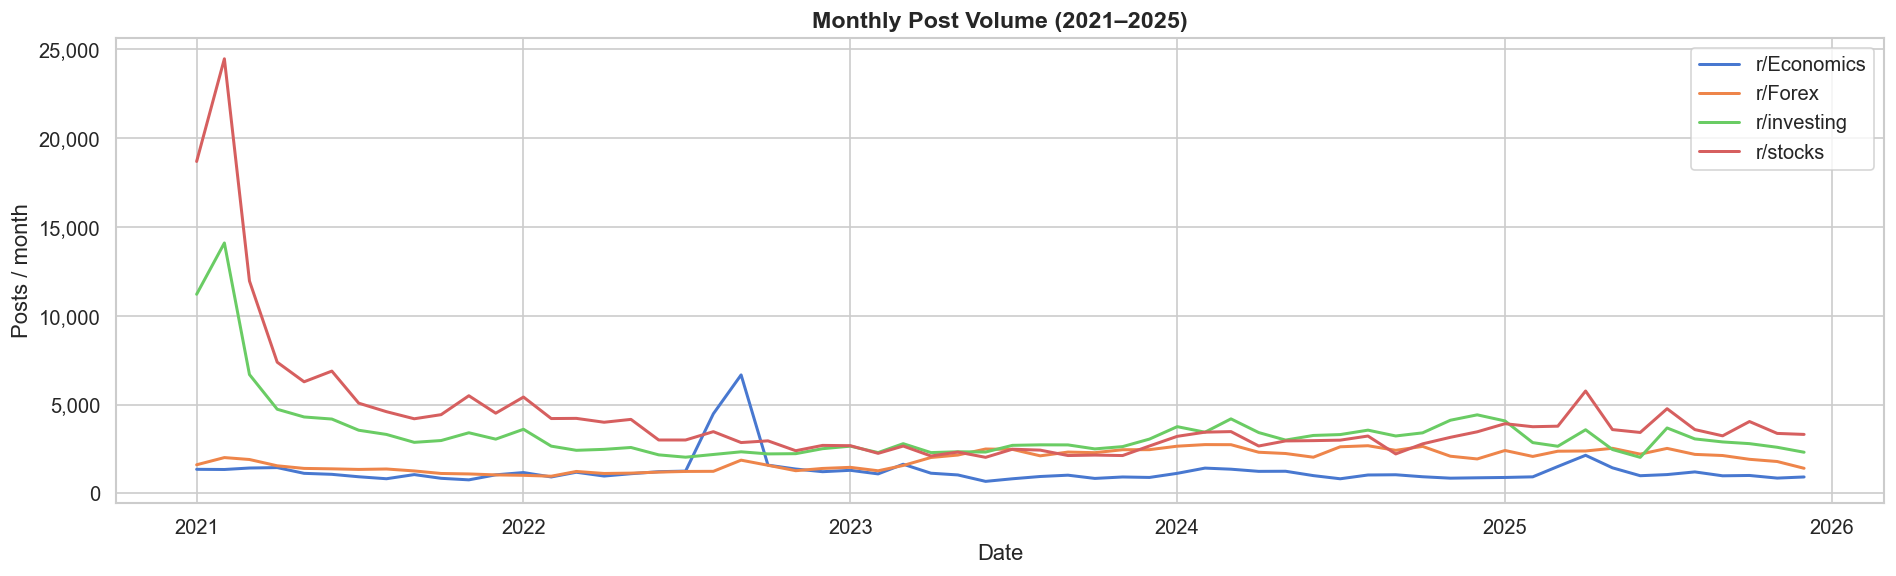

In [8]:
monthly = (
    df_all.groupby(["subreddit", df_all["created_dt"].dt.to_period("M")])
    .size().reset_index(name="posts")
)
monthly["date"] = monthly["created_dt"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
for sr, grp in monthly.groupby("subreddit"):
    ax.plot(grp["date"], grp["posts"], label=f"r/{sr}", linewidth=1.8)
ax.set_title("Monthly Post Volume (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Posts / month")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()

In [9]:
yearly = df_all.groupby(["subreddit", "year"]).size().unstack(fill_value=0)
print("Posts per year:")
print(yearly.to_string())
print("\nYear-over-year growth (%):")
print(yearly.pct_change(axis=1).mul(100).round(1).to_string())

Posts per year:
year         2021   2022   2023   2024   2025
subreddit                                    
Economics   13293  23208  12389  13017  14009
Forex       17152  15327  25142  29172  26016
investing   64395  29491  31104  43143  35045
stocks     103933  42448  28096  36601  46591

Year-over-year growth (%):
year       2021  2022  2023  2024  2025
subreddit                              
Economics   NaN  74.6 -46.6   5.1   7.6
Forex       NaN -10.6  64.0  16.0 -10.8
investing   NaN -54.2   5.5  38.7 -18.8
stocks      NaN -59.2 -33.8  30.3  27.3


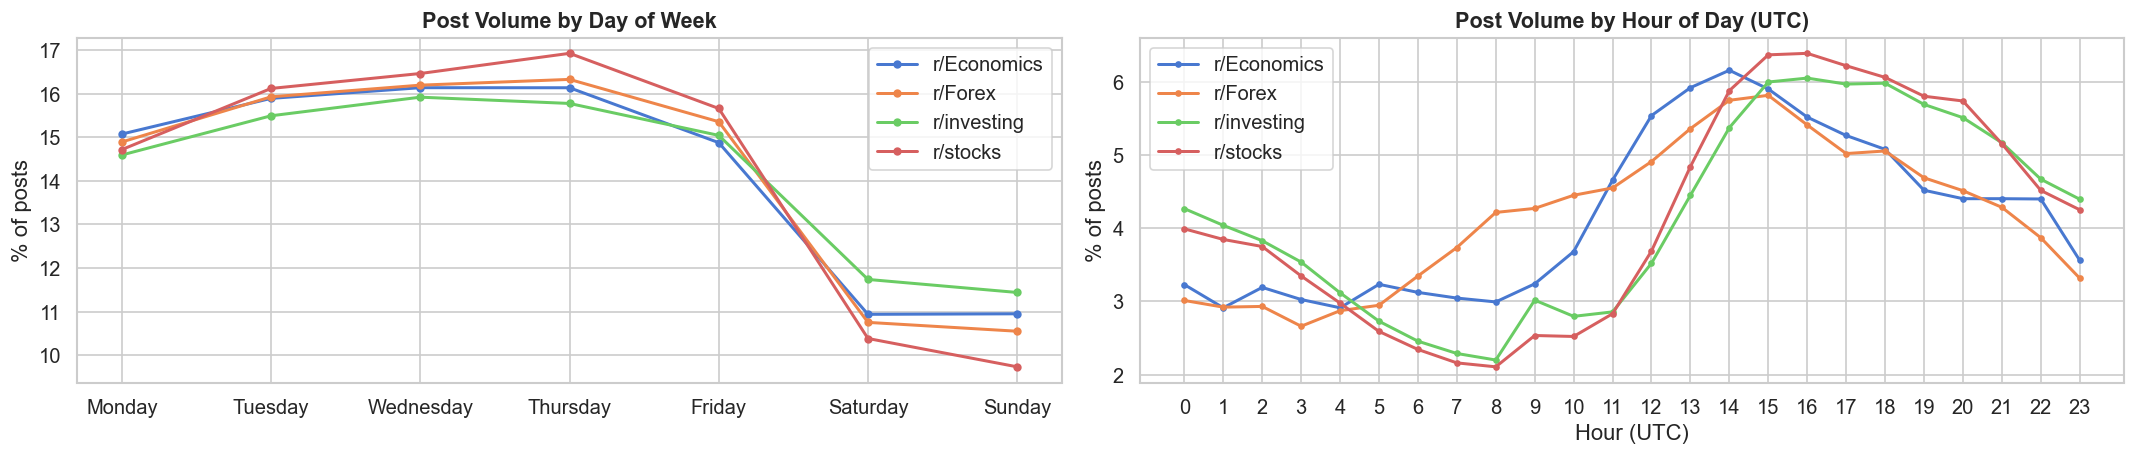

In [10]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_pct = (
    df_all.groupby(["subreddit","weekday"]).size().unstack(fill_value=0)
    .reindex(columns=day_order, fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
)

hour_pct = (
    df_all.groupby(["subreddit","hour"]).size().unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

for sr, row in day_pct.iterrows():
    axes[0].plot(row.index, row.values, label=f"r/{sr}", linewidth=1.8, marker="o", markersize=4)
axes[0].set_title("Post Volume by Day of Week", fontsize=13, fontweight="bold")
axes[0].set_ylabel("% of posts"); axes[0].legend()

for sr, row in hour_pct.iterrows():
    axes[1].plot(row.index, row.values, label=f"r/{sr}", linewidth=1.8, marker="o", markersize=3)
axes[1].set_title("Post Volume by Hour of Day (UTC)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hour (UTC)"); axes[1].set_ylabel("% of posts")
axes[1].set_xticks(range(0, 24)); axes[1].legend()

plt.tight_layout(); plt.show()

In [11]:
print("Weekend posting share (%):")
print(df_all.assign(is_weekend=df_all["weekday"].isin(["Saturday","Sunday"]))
      .groupby("subreddit")["is_weekend"].mean().mul(100).round(1).to_string())
print("\nPeak posting hour per subreddit (UTC):")
print(hour_pct.idxmax(axis=1))

Weekend posting share (%):


subreddit
Economics    21.9
Forex        21.3
investing    23.2
stocks       20.1

Peak posting hour per subreddit (UTC):
subreddit
Economics    14
Forex        15
investing    16
stocks       16
dtype: int32


**Observations:**
- **2021 was a meme-stock mania peak.** r/stocks (104k posts) and r/investing (64k posts) had their highest volumes in 2021 — driven by the GME/AMC short squeeze era. Both collapsed 54–59% in 2022 as speculative retail interest faded. r/Forex followed the opposite pattern — steady growth (+64% in 2023, +16% in 2024), suggesting growing organic FX retail interest.
- **r/Economics spiked in 2022 (+74.6%) then crashed -46.6% in 2023** — likely driven by inflation/rate hike news cycle. The 2022 macro environment (Fed tightening, energy crisis) generated outsized link-sharing activity.
- **All 4 subreddits peak at 14:00–16:00 UTC** (10am–12pm US Eastern) — aligns with the NY market open and early US afternoon session. This is when FX volatility is also highest (London/NY overlap ends ~13:00 UTC). Timing is consistent with US retail traders driving posting behavior.
- **Weekend activity is 20–23% across all subreddits**, close to the 2/7 = 28.6% baseline expected if posting were uniform. All communities post moderately less on weekends — they are market-aware but not completely inactive. r/Forex at 21.3% weekend shows traders still discuss positions over the weekend despite markets being closed.

## 5. Engagement Analysis

In [12]:
eng = df_all.groupby("subreddit").agg(
    score_p25     = ("score",        lambda x: x.quantile(0.25)),
    score_median  = ("score",        "median"),
    score_mean    = ("score",        "mean"),
    score_p95     = ("score",        lambda x: x.quantile(0.95)),
    score_max     = ("score",        "max"),
    comments_med  = ("num_comments", "median"),
    comments_mean = ("num_comments", "mean"),
    comments_p95  = ("num_comments", lambda x: x.quantile(0.95)),
    upvote_ratio  = ("upvote_ratio", "mean"),
).round(1)
print(eng.to_string())

           score_p25  score_median  score_mean  score_p95  score_max  comments_med  comments_mean  comments_p95  upvote_ratio
subreddit                                                                                                                    
Economics        1.0           1.0       241.8     1055.0      55334           1.0           41.9         240.0           0.9
Forex            1.0           1.0         6.6       26.0       1057           1.0            8.0          38.0           0.9
investing        1.0           1.0        16.6       25.0      26836           1.0           13.0          54.0           0.9
stocks           1.0           1.0        44.1       77.0     101741           0.0           21.0          87.0           0.9


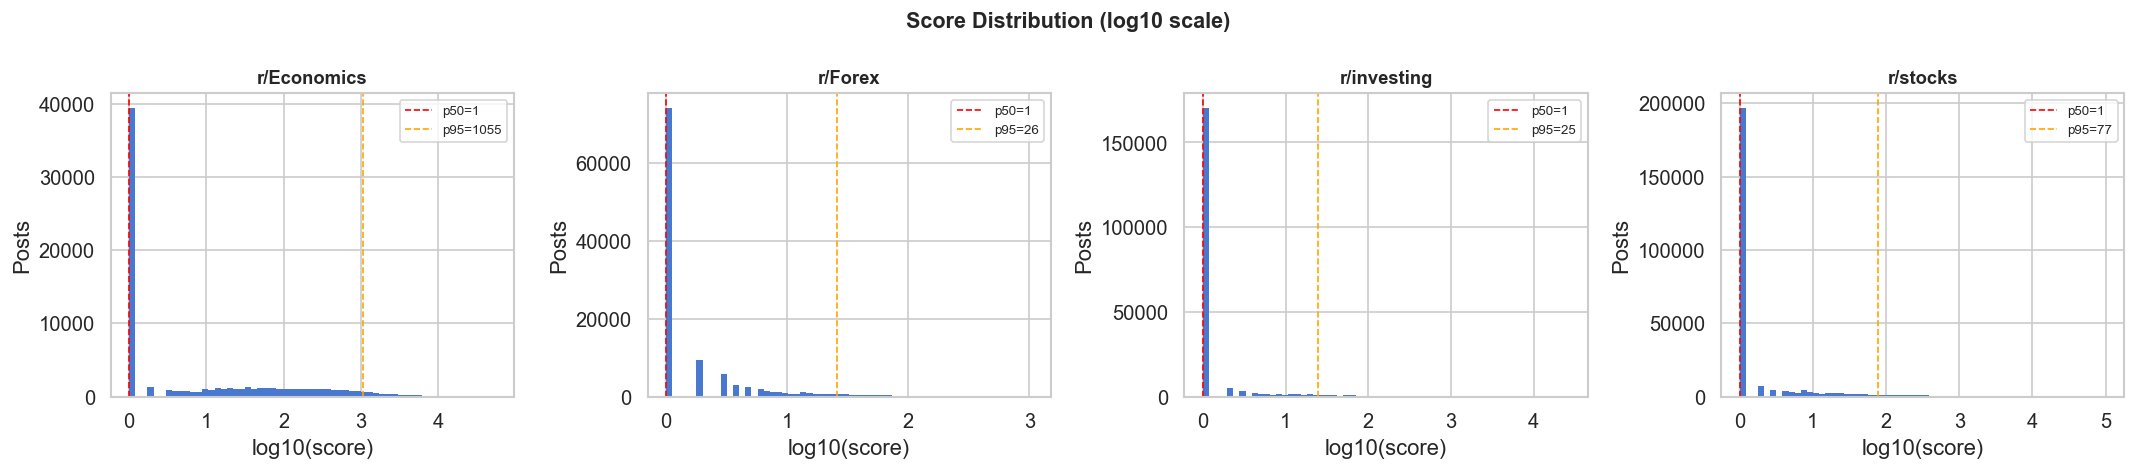

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (sr, grp) in zip(axes, df_all.groupby("subreddit")):
    scores = grp["score"].clip(lower=1)
    ax.hist(np.log10(scores), bins=60, color=sns.color_palette("muted")[0], edgecolor="none")
    ax.set_title(f"r/{sr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("log10(score)"); ax.set_ylabel("Posts")
    p50 = scores.median(); p95 = scores.quantile(0.95)
    ax.axvline(np.log10(max(p50,1)), color="red",    linestyle="--", lw=1, label=f"p50={p50:.0f}")
    ax.axvline(np.log10(max(p95,1)), color="orange", linestyle="--", lw=1, label=f"p95={p95:.0f}")
    ax.legend(fontsize=8)
fig.suptitle("Score Distribution (log10 scale)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

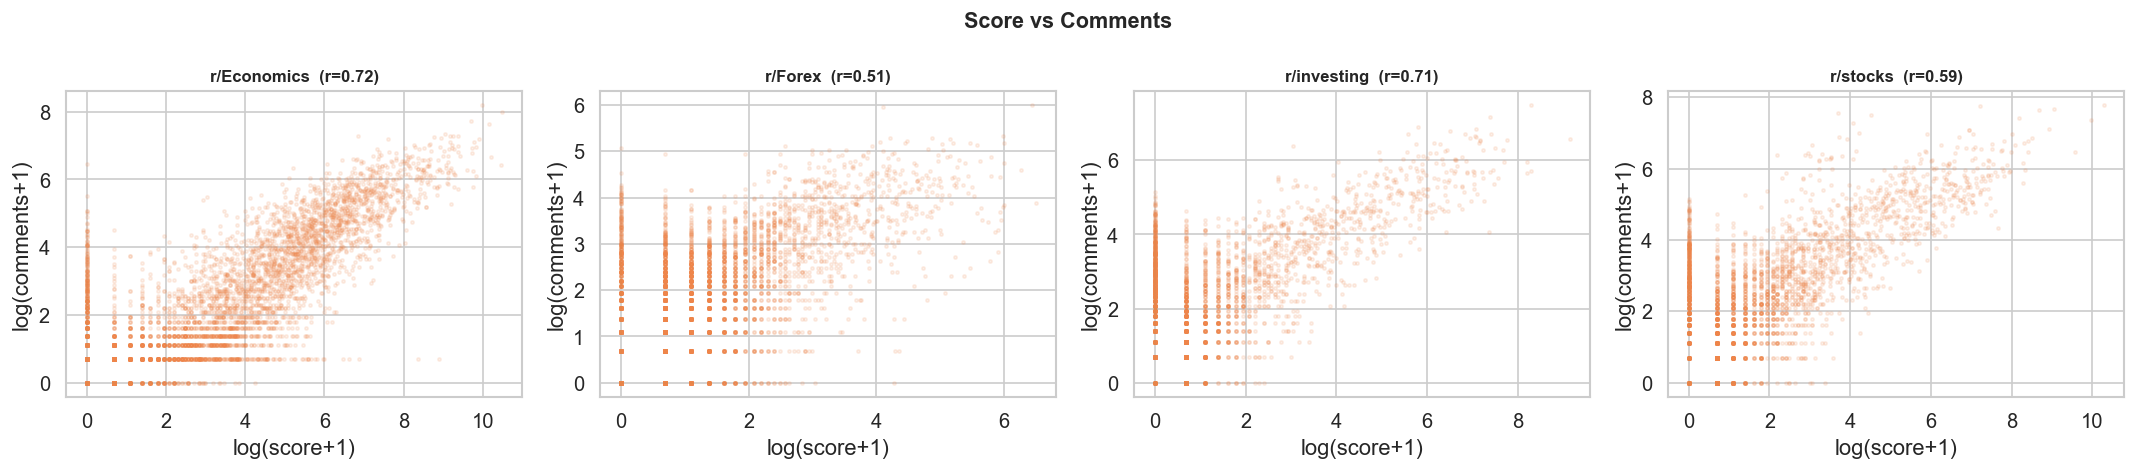

In [14]:
# Score vs comments scatter — are upvotes and comments correlated?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (sr, grp) in zip(axes, df_all.groupby("subreddit")):
    s = grp.sample(min(8000, len(grp)), random_state=42)
    ax.scatter(np.log1p(s["score"]), np.log1p(s["num_comments"]),
               alpha=0.12, s=4, color=sns.color_palette("muted")[1])
    corr = grp[["score","num_comments"]].corr().iloc[0,1]
    ax.set_title(f"r/{sr}  (r={corr:.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("log(score+1)"); ax.set_ylabel("log(comments+1)")
fig.suptitle("Score vs Comments", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [15]:
# Engagement by post type
eng_type = df_all.groupby(["subreddit","post_type"]).agg(
    n               = ("id",           "count"),
    score_median    = ("score",        "median"),
    score_mean      = ("score",        "mean"),
    comments_median = ("num_comments", "median"),
).round(1)
print(eng_type.to_string())

                          n  score_median  score_mean  comments_median
subreddit post_type                                                   
Economics external    73241           1.0       249.8              1.0
          gallery       158           1.0        10.0              0.0
          image        1151           1.0         1.0              1.0
          text          909           1.0        53.0              1.0
          video         457           1.0        17.4              0.0
Forex     external     4259           1.0         2.4              0.0
          gallery      9943           1.0        10.3              1.0
          image       26074           1.0        13.9              2.0
          text        70657           1.0         3.4              1.0
          video        1876           1.0        18.1              1.0
investing external        4         147.5       471.2             10.0
          text       203174           1.0        16.6              1.0
stocks

**Observations:**
- **All subreddits have median score = 1 and upvote ratio = 0.9.** The communities are not actively downvoting — posts just die with no engagement. Score is not a quality filter; it's a popularity filter for the rare breakout post.
- **r/Economics is a viral machine when it hits.** Mean score of 241.8 vs median of 1 — one of the most extreme distributions observed. The p95 is 1,055 and max is 55,334. A handful of posts attract massive macro-level attention. These viral Economics posts are strong event signals (Fed decisions, CPI prints, banking crises).
- **r/stocks has the highest score ceiling (max 101,741)** but only mean 44.1. Meme stocks and viral trades drive occasional monster posts.
- **External links on r/stocks average 1,088 score** (only 78 posts) — the few external links allowed in a self-post-only community are curated and get massive engagement. High signal.
- **In r/Forex, images (chart screenshots) get higher median engagement (comments median=2) than text posts (comments median=1)** — visual trading setups generate more discussion than text analysis. Videos get the highest mean score (18.1). Visual content is more engaging.
- **Score and comments are weakly correlated across all subreddits** — they measure different things. High scores = broad community approval; high comments = debate/controversy. Both are independently useful as signal dimensions.

## 6. Author Analysis

In [16]:
bots = {"AutoModerator", "[deleted]", "[removed]", None}

for sr, grp in df_all.groupby("subreddit"):
    clean = grp[~grp["author"].isin(bots)]
    top   = clean.groupby("author")["id"].count().sort_values(ascending=False).head(10)
    n_authors   = clean["author"].nunique()
    top10_share = top.sum() / len(grp) * 100
    print(f"\nr/{sr}  ({n_authors:,} unique authors | top-10 = {top10_share:.1f}% of all posts)")
    for a, n in top.items():
        print(f"    {a:<32} {n:>5}")


r/Economics  (16,981 unique authors | top-10 = 18.3% of all posts)
    TheWorldPost24                    5015
    latestasianews                    3310
    JUHERMILA                         1377
    marketrent                        1249
    AndrewTFTC                         565
    joe4942                            562
    mberre                             552
    Majano57                           451
    donutloop                          403
    Narrow-Spend-4813                  399



r/Forex  (44,796 unique authors | top-10 = 1.7% of all posts)
    ivuser1                            773
    AresOpsiyon                        196
    qasimp1992                         176
    Ill-Assistant-5733                 137
    TheTradingHood                     127
    Flashy-Dimension-810               125
    guna_sk                            116
    doglover5784                       100
    Infinite-Carrot1664                 97
    ForexKingEa                         95



r/investing  (111,056 unique authors | top-10 = 1.1% of all posts)
    Sandra__PS                         603
    RubFormer3559                      452
    DependentOptimal8506               230
    tradewiseforex                     188
    dailystockalert                    187
    Ok_Assignment4100                  178
    Alert-Variation-6339               132
    EfficientElk4243                   115
    huongdinhant                       106
    StocksHighAlert                    102



r/stocks  (134,585 unique authors | top-10 = 1.6% of all posts)
    Puginator                          956
    Queengenademedicieth               643
    bigbear0083                        512
    WinningWatchlist                   350
    apooroldinvestor                   345
    _hiddenscout                       291
    WickedSensitiveCrew                288
    Progress_8                         265
    psychotrader00                     212
    callsonreddit                      207


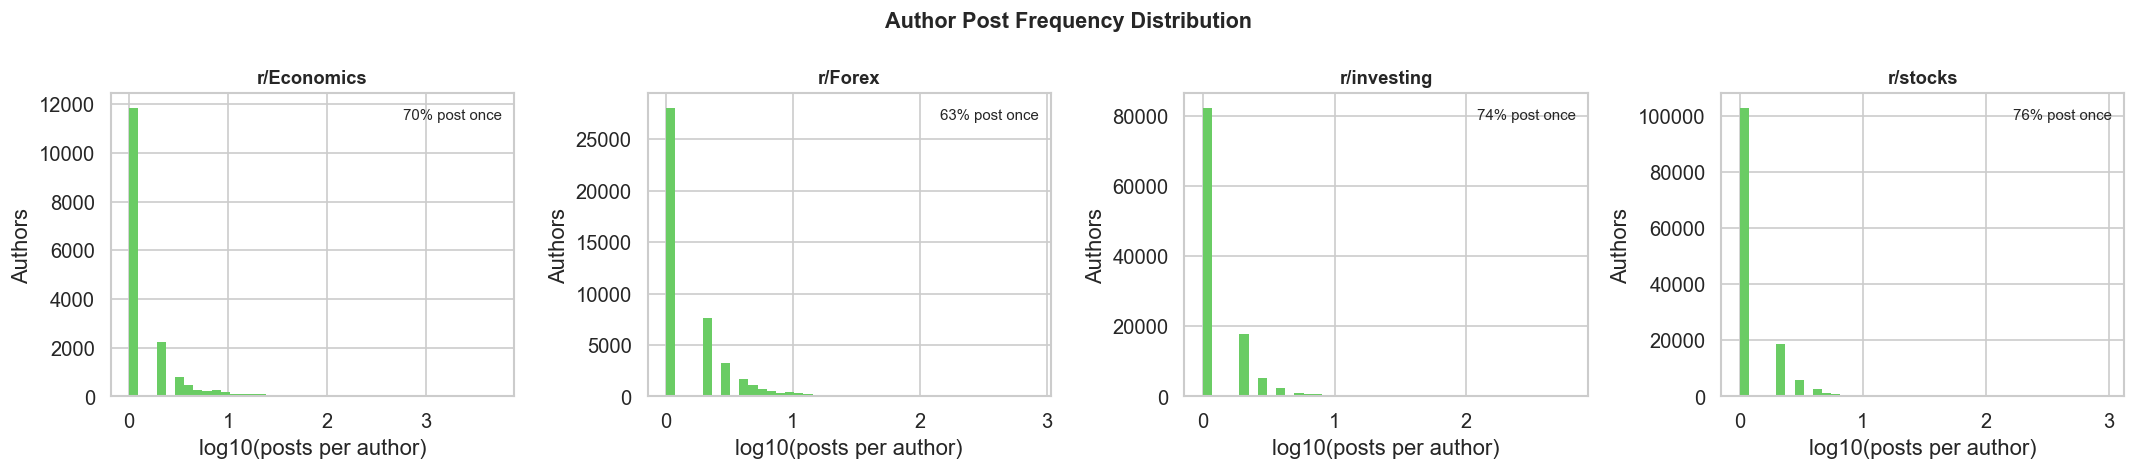

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (sr, grp) in zip(axes, df_all.groupby("subreddit")):
    freq = grp[~grp["author"].isin(bots)].groupby("author")["id"].count()
    ax.hist(np.log10(freq.clip(lower=1)), bins=40, color=sns.color_palette("muted")[2], edgecolor="none")
    ax.set_title(f"r/{sr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("log10(posts per author)"); ax.set_ylabel("Authors")
    pct_once = (freq == 1).mean() * 100
    ax.text(0.97, 0.95, f"{pct_once:.0f}% post once", transform=ax.transAxes, ha="right", va="top", fontsize=9)
fig.suptitle("Author Post Frequency Distribution", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Observations:**
- **r/Economics top authors are news bots/scrapers.** `TheWorldPost24` (5,015 posts) and `latestasianews` (3,310 posts) are automated accounts mass-posting news links. The top 10 account for 18.3% of all posts — extreme concentration driven by bots, not humans. These accounts should be flagged and excluded from signal analysis.
- **r/Forex is the healthiest community** — 44,796 unique authors, top-10 only 1.7% of posts. No single account dominates. The top poster `ivuser1` has 773 posts which is still ~1 post per 2 days over 5 years — plausibly human but prolific.
- **r/investing and r/stocks show spam patterns.** `tradewiseforex`, `dailystockalert`, `StocksHighAlert`, `WinningWatchlist`, `callsonreddit` — names that suggest promotional/alert bots. They post at 100–600 posts over the period, which is high but not extreme.
- **The vast majority of users post once and leave** across all subreddits — typical of Reddit communities. Signal should be weighted by author posting history and consistency, not just single posts.

## 7. Flair & Topic Distribution


r/Economics  (52.2% posts have flair)
    News                                 23,871
    Research                              3,188
    Editorial                             3,139
    Blog                                  3,117
    Statistics                            2,192
    Research Summary                      1,540
    Removed -- Rule II                      961
    Interview                               755
    Removed -- Rule III                     382
    Removed -- Rule I                       310

r/Forex  (98.6% posts have flair)
    Questions                            41,650
    Charts and Setups                    27,359
    Prop Firms                            9,152
    Fundamental Analysis                  9,022
    OTHER/META                            8,900
    P/L Porn                              7,137
    Brokers                               6,266
    MEMES                                 1,777
    ANNOUNCEMENTS                             8
    START HERE

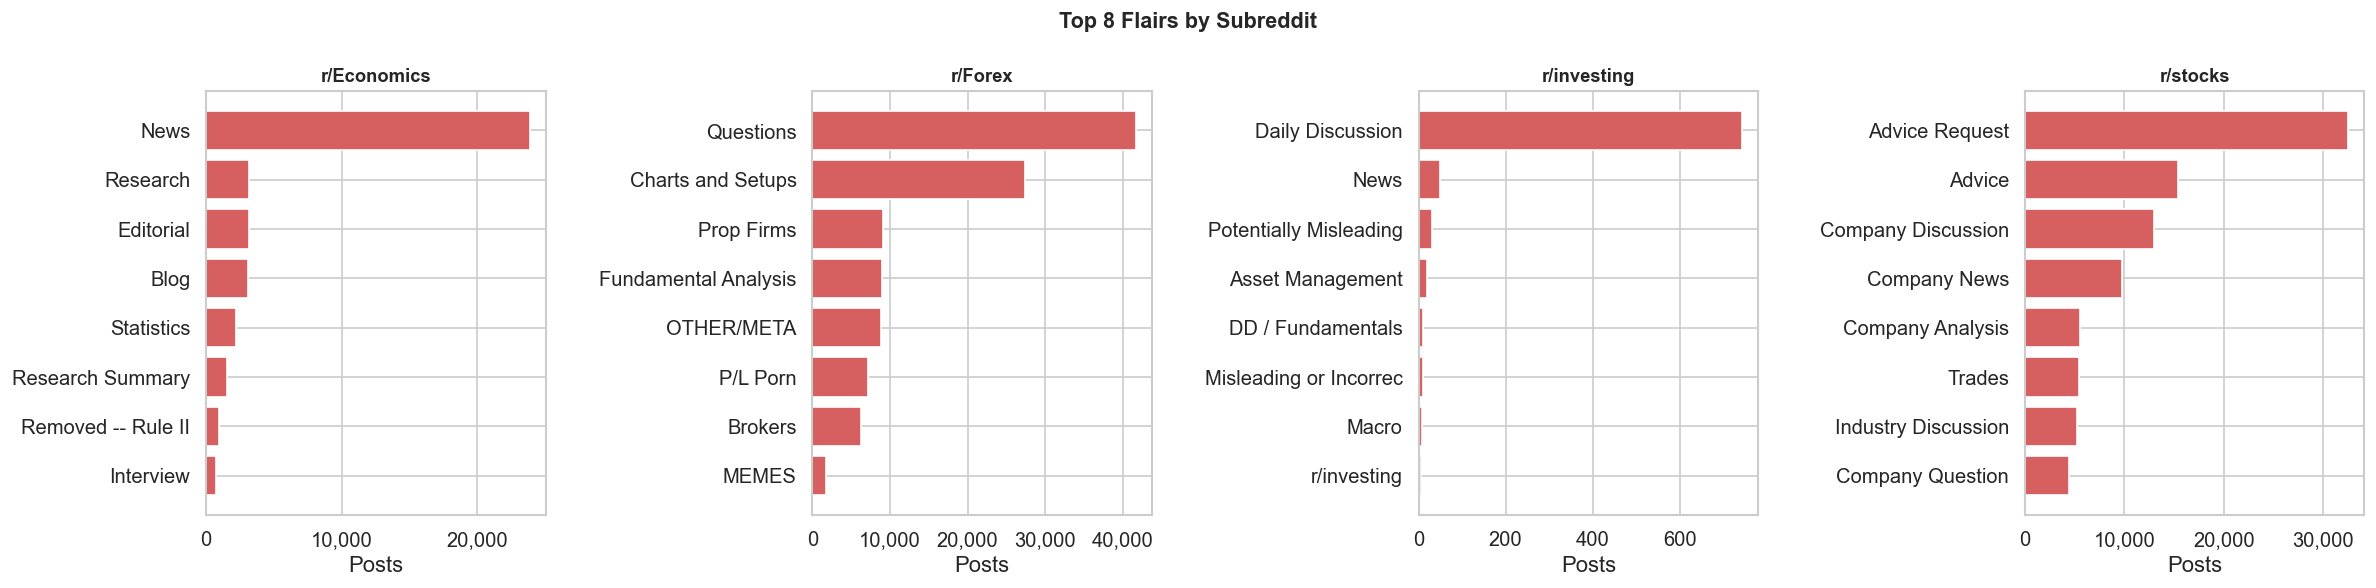

In [18]:
for sr, grp in df_all.groupby("subreddit"):
    top = grp["link_flair_text"].dropna().value_counts().head(10)
    flair_coverage = grp["link_flair_text"].notna().mean() * 100
    print(f"\nr/{sr}  ({flair_coverage:.1f}% posts have flair)")
    for flair, n in top.items():
        print(f"    {str(flair):<35} {n:>7,}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (sr, grp) in zip(axes, df_all.groupby("subreddit")):
    top    = grp["link_flair_text"].dropna().value_counts().head(8)
    labels = [str(l)[:22] for l in top.index]
    ax.barh(labels[::-1], top.values[::-1], color=sns.color_palette("muted")[3])
    ax.set_title(f"r/{sr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Posts")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.suptitle("Top 8 Flairs by Subreddit", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Observations:**
- **r/Forex has the best flair taxonomy for signal extraction (98.6% coverage).** Flairs are granular and directly actionable: `Questions` (41k — retail confusion/education), `Charts and Setups` (27k — technical analysis posts), `Fundamental Analysis` (9k — macro-driven trades), `P/L Porn` (7k — real trade outcomes with results). The `Charts and Setups` and `Fundamental Analysis` flairs are the highest-priority signal sources.
- **`Prop Firms` flair has 9,152 posts** — a uniquely r/Forex topic about funded accounts. Likely contains sentiment around prop firm market conditions (volatility preferences, risk-on/off) but is community-specific noise.
- **r/stocks flair is company-centric** (`Advice Request`, `Company Discussion`, `Company News`) — useful for equity sentiment but weak for FX. Macro spillover from `Industry Discussion` and `Industry News` is the FX-relevant portion.
- **r/investing has almost no flair (0.4%)** — the community doesn't use it consistently. Cannot segment by topic. Must rely entirely on text content.
- **r/Economics flair includes `Removed -- Rule II/III` as top entries** — the moderation removal reasons appear in flair, confirming the high deletion rate seen earlier is moderation-driven.

## 8. Content Analysis

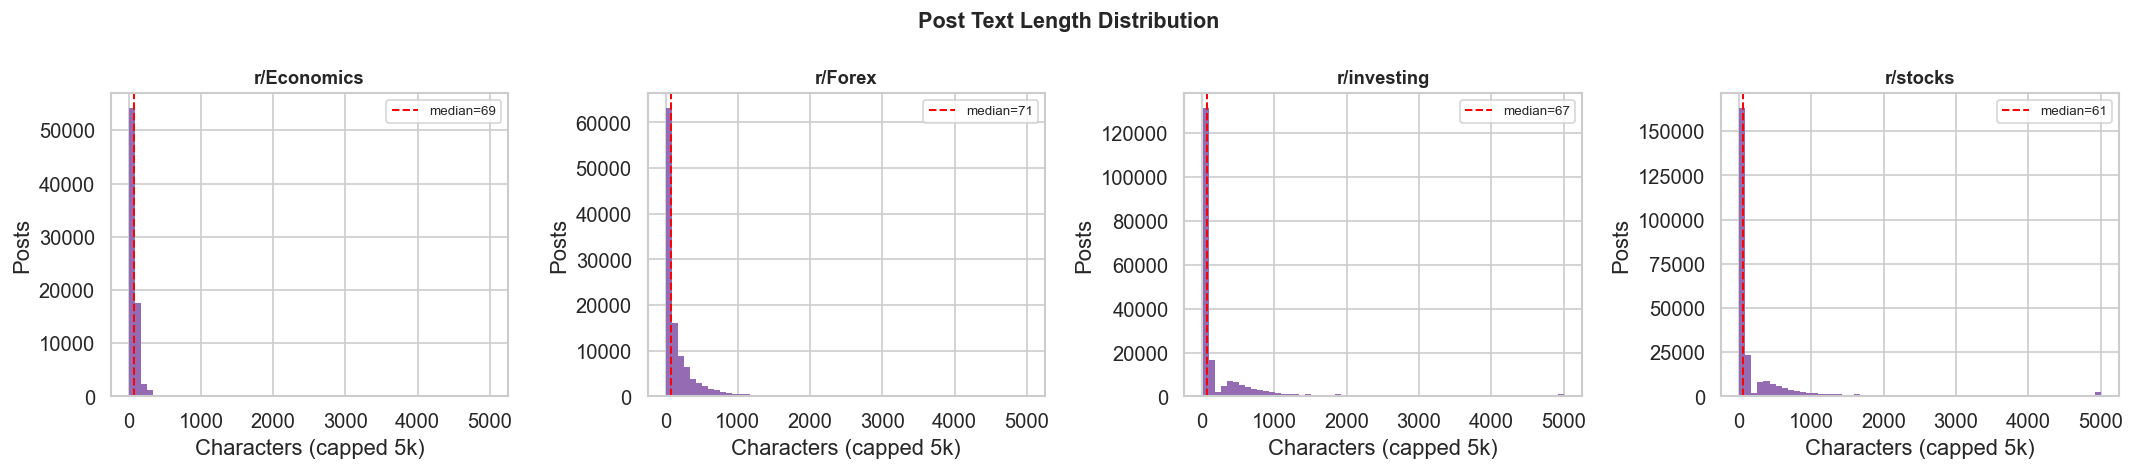


Text length stats by subreddit:
              count   mean     std   min   25%   50%    75%      max
subreddit                                                           
Economics   75916.0   85.0   136.0   2.0  53.0  69.0   89.0  10677.0
Forex      112809.0  212.0   511.0   2.0  37.0  71.0  213.0  38681.0
investing  203178.0  308.0   817.0  11.0  46.0  67.0  314.0  39982.0
stocks     257669.0  383.0  1214.0   5.0  37.0  61.0  300.0  39632.0


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (sr, grp) in zip(axes, df_all.groupby("subreddit")):
    lengths = grp["text_length"].clip(upper=5000)
    ax.hist(lengths, bins=60, color=sns.color_palette("muted")[4], edgecolor="none")
    ax.set_title(f"r/{sr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Characters (capped 5k)"); ax.set_ylabel("Posts")
    med = lengths.median()
    ax.axvline(med, color="red", linestyle="--", lw=1.2, label=f"median={med:.0f}")
    ax.legend(fontsize=8)
fig.suptitle("Post Text Length Distribution", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nText length stats by subreddit:")
print(df_all.groupby("subreddit")["text_length"].describe().round(0).to_string())

In [20]:
# Top external domains — what news sources does each community trust?
ext = df_all[df_all["post_type"] == "external"]
for sr, grp in ext.groupby("subreddit"):
    top = grp["domain"].value_counts().head(12)
    print(f"\nr/{sr}  ({len(grp):,} external posts):")
    for dom, n in top.items():
        print(f"    {dom:<40} {n:>6,}")


r/Economics  (73,241 external posts):
    en.vallevirtual.co                        5,015
    rajacreator.com                           3,310
    youtu.be                                  3,146
    bloomberg.com                             2,904
    cnbc.com                                  2,675
                                              2,450
    reuters.com                               2,434
    youtube.com                               2,190
    wsj.com                                   1,478
    finance.yahoo.com                         1,280
    nytimes.com                               1,233
    ft.com                                    1,084

r/Forex  (4,259 external posts):
    youtube.com                                 528
    youtu.be                                    475
    t.me                                        350
    tradingview.com                             147
                                                142
    thetradinghood.com                     

**Observations:**
- **Median text length is 61–71 characters across all subreddits** — shorter than a tweet. The bulk of posts are title-only or near-title-only. The distributions are right-skewed: a small fraction of posts contain long-form analysis (up to 40k chars). r/stocks has the heaviest tail (std=1,214) — DD posts can be very long.
- **r/Economics external links confirm the bot problem.** `en.vallevirtual.co` (5,015 posts = TheWorldPost24 bot) and `rajacreator.com` (3,310 = latestasianews bot) are the top two domains — not legitimate news sources. After stripping bots, the real top sources are Bloomberg, CNBC, Reuters, WSJ, NYT, FT — high-quality financial press. These are strong macro signal sources.
- **r/Forex external links are dominated by YouTube/Telegram/Discord** — the community drives traffic to video content and private groups, not news. `tradingview.com` (147 posts) and `t.me` (350 Telegram links) confirm retail traders sharing setups and signals via external platforms.
- **r/stocks external domains include `self.wallstreetbets`, `self.investing`, `self.pennystocks`** — cross-posts from other Reddit communities. The `localhost` entries are data artefacts. No real external news domain dominates, confirming the self-post-only nature of the community.

## 9. Cross-Subreddit Comparison

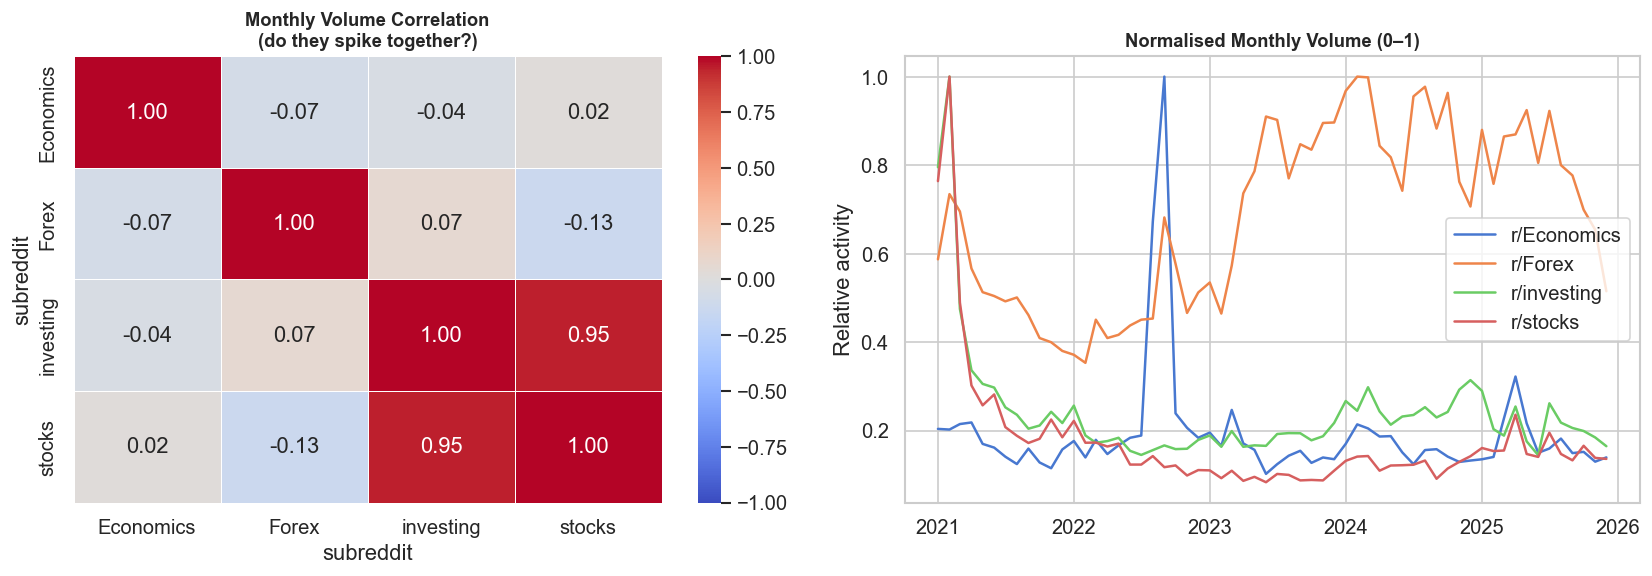

subreddit  Economics  Forex  investing  stocks
subreddit                                     
Economics      1.000 -0.073     -0.041   0.018
Forex         -0.073  1.000      0.065  -0.132
investing     -0.041  0.065      1.000   0.953
stocks         0.018 -0.132      0.953   1.000


In [21]:
# Monthly volume correlation — do subreddits spike at the same time?
monthly_pivot = (
    df_all.groupby(["subreddit", df_all["created_dt"].dt.to_period("M")])
    .size().unstack(level=0).fillna(0)
)
corr = monthly_pivot.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Monthly Volume Correlation\n(do they spike together?)", fontsize=11, fontweight="bold")

# Normalised monthly volume — overlay for visual inspection
norm = monthly_pivot.div(monthly_pivot.max())
for col in norm.columns:
    axes[1].plot(norm.index.to_timestamp(), norm[col], label=f"r/{col}", linewidth=1.5)
axes[1].set_title("Normalised Monthly Volume (0–1)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Relative activity"); axes[1].legend()

plt.tight_layout(); plt.show()
print(corr.round(3).to_string())

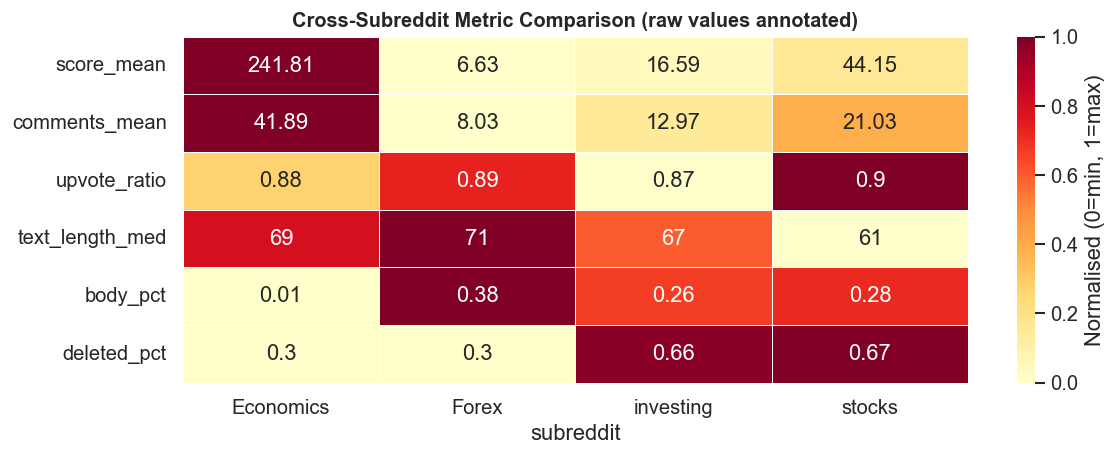

In [22]:
# Normalised engagement comparison heatmap
metrics = df_all.groupby("subreddit").agg(
    score_mean      = ("score",        "mean"),
    comments_mean   = ("num_comments", "mean"),
    upvote_ratio    = ("upvote_ratio", "mean"),
    text_length_med = ("text_length",  "median"),
    body_pct        = ("has_body",     "mean"),
    deleted_pct     = ("is_deleted",   "mean"),
)
norm_m = (metrics - metrics.min()) / (metrics.max() - metrics.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(norm_m.T, annot=metrics.T.round(2), fmt="g",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalised (0=min, 1=max)"})
ax.set_title("Cross-Subreddit Metric Comparison (raw values annotated)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

**Observations:**
- **r/investing and r/stocks move in near-perfect lockstep (r=0.953).** They are functionally the same community for signal purposes — both driven by the same US retail equity crowd. Aggregating them gives a single "US retail equity sentiment" signal without meaningful information loss.
- **r/Forex and r/Economics are uncorrelated with everything** (all correlations between -0.13 and +0.07). They respond to different events and different audiences. r/Forex is FX-specific retail; r/Economics is driven by macro news and bots. These are genuinely independent signal channels.
- **r/Economics has the highest mean score (241.8) but worst content quality** (1.4% body text, 30% deleted, bot-dominated). High score is driven by viral macro news posts — useful as an event detector but not for NLP text analysis.
- **r/Forex has the lowest mean score (6.6) but best content quality** — diverse post types, real traders, granular flairs, 37.9% body text. It is the richest subreddit for FX-specific signal despite lower virality.

## 10. Signal-Relevant Patterns

Viral posts (top 1% score): 6,504
              n  score_min  score_max
subreddit                            
Economics   760       4382      55334
Forex      1131        113       1057
investing  2034        365      26836
stocks     2579        849     101741


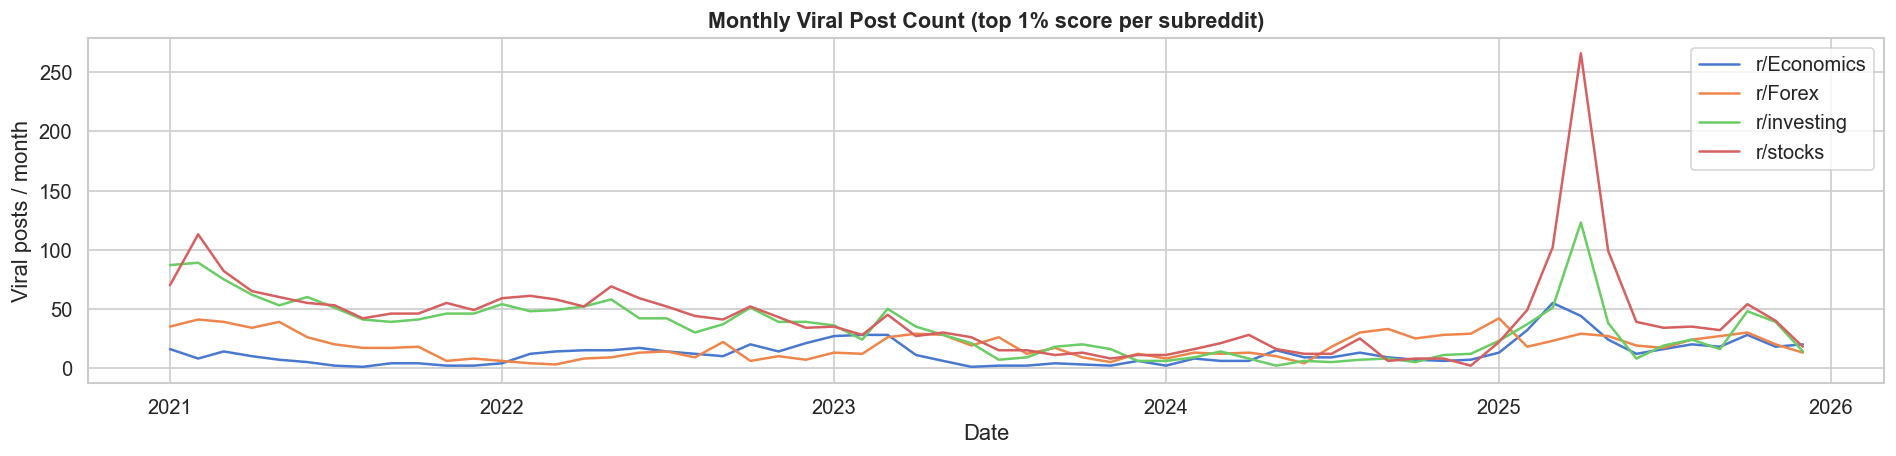

In [23]:
# Viral posts — top 1% by score per subreddit — monthly count over time
threshold = df_all.groupby("subreddit")["score"].transform(lambda x: x.quantile(0.99))
viral = df_all[df_all["score"] >= threshold].copy()

print(f"Viral posts (top 1% score): {len(viral):,}")
print(viral.groupby("subreddit").agg(n=("id","count"), score_min=("score","min"), score_max=("score","max")).to_string())

viral_m = (
    viral.groupby(["subreddit", viral["created_dt"].dt.to_period("M")])
    .size().unstack(level=0).fillna(0)
)
fig, ax = plt.subplots(figsize=(16, 4))
for col in viral_m.columns:
    ax.plot(viral_m.index.to_timestamp(), viral_m[col], label=f"r/{col}", linewidth=1.5)
ax.set_title("Monthly Viral Post Count (top 1% score per subreddit)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Viral posts / month"); ax.legend()
plt.tight_layout(); plt.show()

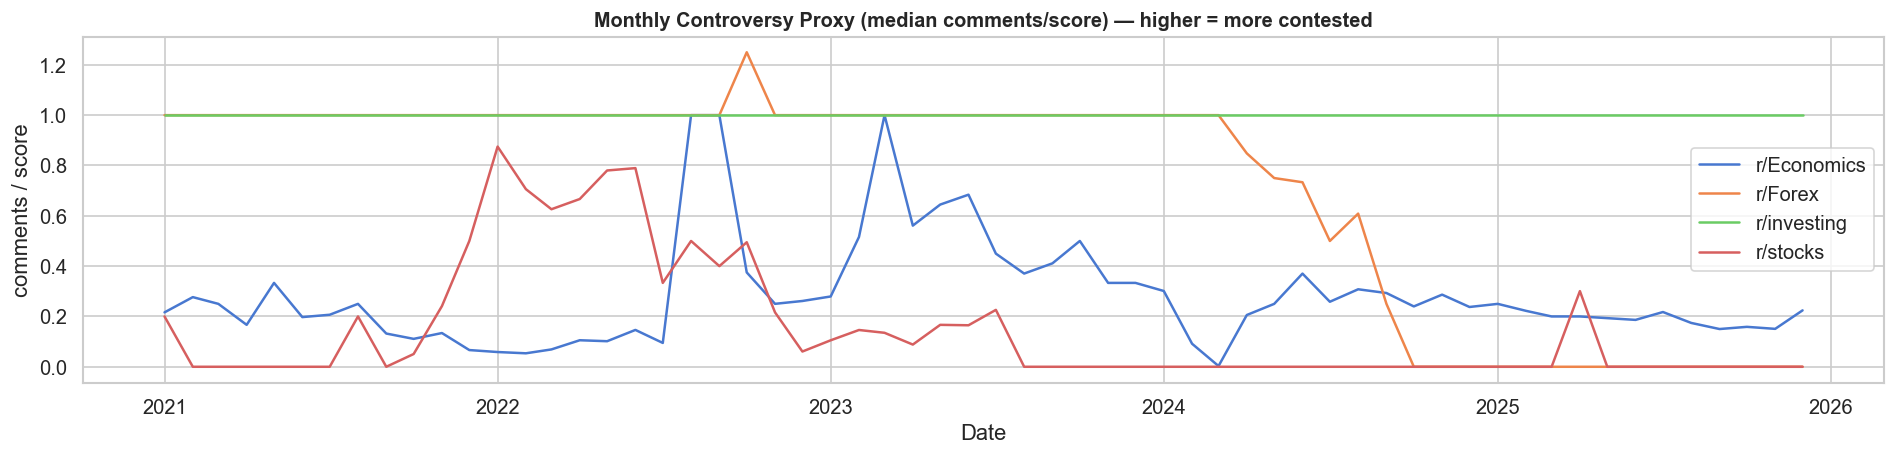


Overall controversy by subreddit (median):
subreddit
Economics    0.281
Forex        0.929
investing    1.000
stocks       0.000


In [24]:
# Controversy proxy — high comments relative to score = contested/divisive topic
df_all["controversy"] = df_all["num_comments"] / df_all["score"].clip(lower=1)

controversy_m = (
    df_all.groupby(["subreddit", df_all["created_dt"].dt.to_period("M")])["controversy"]
    .median().unstack(level=0)
)

fig, ax = plt.subplots(figsize=(16, 4))
for col in controversy_m.columns:
    ax.plot(controversy_m.index.to_timestamp(), controversy_m[col], label=f"r/{col}", linewidth=1.5)
ax.set_title("Monthly Controversy Proxy (median comments/score) — higher = more contested", fontsize=12, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("comments / score"); ax.legend()
plt.tight_layout(); plt.show()

print("\nOverall controversy by subreddit (median):")
print(df_all.groupby("subreddit")["controversy"].median().round(3).to_string())

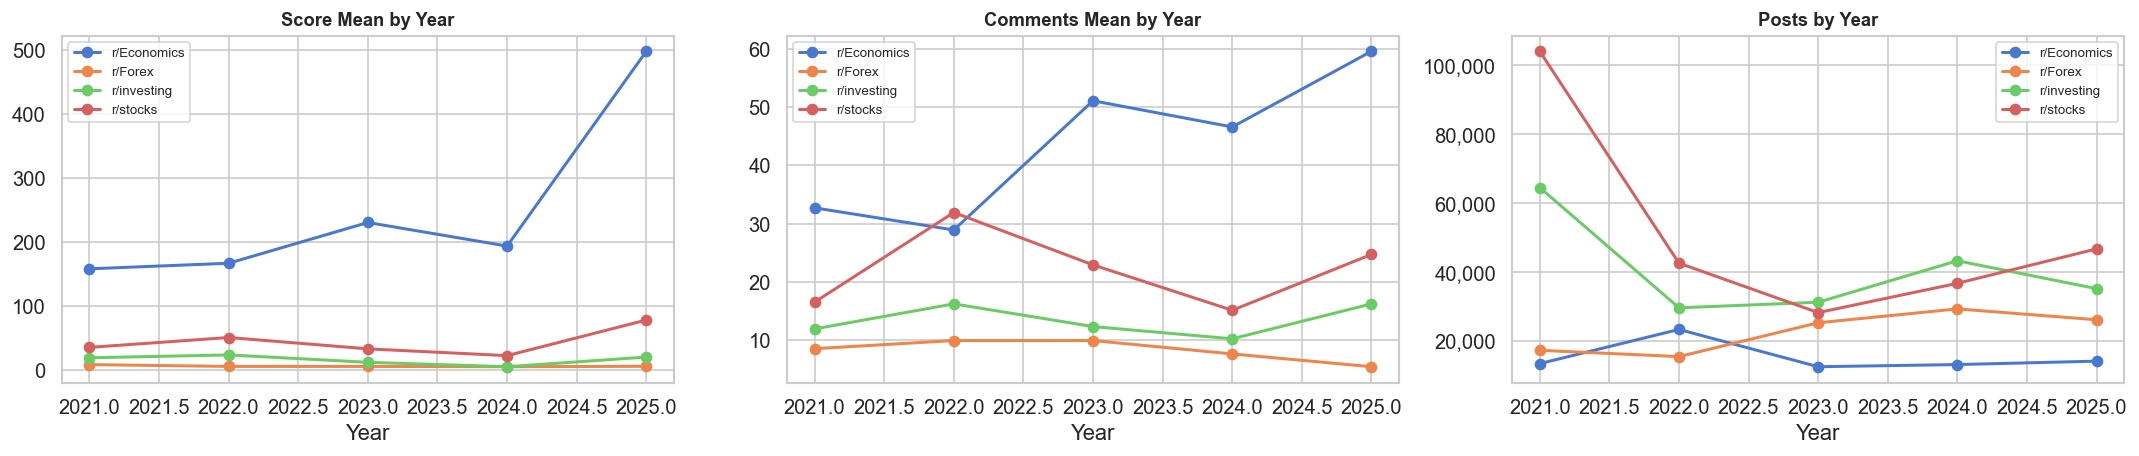

In [25]:
# Engagement trend over years — is attention growing or dying?
yearly_eng = df_all.groupby(["subreddit", "year"]).agg(
    score_mean    = ("score",        "mean"),
    comments_mean = ("num_comments", "mean"),
    posts         = ("id",           "count"),
).unstack(level=0).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric in zip(axes, ["score_mean", "comments_mean", "posts"]):
    for sr in yearly_eng[metric].columns:
        ax.plot(yearly_eng.index, yearly_eng[metric][sr], label=f"r/{sr}", marker="o", linewidth=1.8)
    label = metric.replace("_", " ").title()
    ax.set_title(f"{label} by Year", fontsize=11, fontweight="bold")
    ax.set_xlabel("Year"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout(); plt.show()

In [26]:
# Sample top viral posts per subreddit — what content actually breaks through?
print("TOP 5 VIRAL POSTS PER SUBREDDIT\n")
for sr, grp in df_all.groupby("subreddit"):
    top5 = grp.nlargest(5, "score")[["title", "score", "num_comments", "created_dt", "link_flair_text"]]
    print(f"{'='*70}")
    print(f"r/{sr}")
    print(f"{'='*70}")
    for _, row in top5.iterrows():
        dt  = row["created_dt"].strftime("%Y-%m-%d")
        flair = f"[{row['link_flair_text']}]" if pd.notna(row["link_flair_text"]) else ""
        print(f"  score={row['score']:>6,}  comments={row['num_comments']:>5,}  {dt}  {flair}")
        print(f"    {row['title'][:100]}")
    print()

TOP 5 VIRAL POSTS PER SUBREDDIT



r/Economics
  score=55,334  comments=1,599  2024-07-15  [News]
    Biden to remove tax benefit from landlords who raise their tenants’ rent more than 5 per cent per ye
  score=54,085  comments=3,919  2025-02-20  
    Economist Warns That Elon Musk Is About to Cause a "Deep, Deep Recession"
  score=47,866  comments=3,227  2021-01-07  
    65% of Americans support monthly $2,000 COVID stimulus payments, new poll shows
  score=42,687  comments=1,025  2025-12-01  [News]
    Costco sues the Trump administration, seeking a refund of tariffs
  score=41,448  comments=  386  2022-07-08  [Research Summary]
    Fed report finds 75% of $800 billion Paycheck Protection Program didn't reach employees



r/Forex
  score= 1,057  comments=   95  2025-01-02  [MEMES]
    Lmao😂
  score= 1,031  comments=   51  2021-02-08  [MEMES]
    It Be Like That
  score= 1,007  comments=  314  2025-04-11  [Questions]
    What in the actual F*** is this?
  score= 1,002  comments=  230  2024-10-21  [P/L Porn]
    After 6 years of trading, i finally found consistency 🔥
  score=   965  comments=   27  2021-01-29  [MEMES]
    How dare you !!!



r/investing
  score=26,836  comments=5,507  2021-01-28  
    Robinhood and other brokers literally blocking purchase of $GME, $NOK, $BB, $AMC; allow sells
  score= 9,275  comments=  718  2021-02-11  
    Historically it's way better to invest at market close than at market open, most gains occur overnig
  score= 9,149  comments=  760  2021-01-31  
    Jim Cramer Gave an Interview in 2006 on how the Hedge Funds Manipulate the Markets
  score= 8,986  comments=  827  2025-07-10  
    Today I made $1m gains by selling my entire Nvidia portfolio
  score= 8,038  comments=2,468  2021-02-01  
    Emotional involvement has never been this high, please understand the risk involved.



r/stocks
  score=101,741  comments=4,376  2021-02-01  
    It's fucking awful seeing the "Silver" misinformation campaign everywhere I look
  score=88,310  comments=6,798  2021-01-28  [Discussion]
    Companies try to prevent people from trading GME and AMC
  score=50,105  comments=3,666  2025-04-10  [Broad market news]
    PRESIDENT TRUMP JUST ASKED THE SUPREME COURT FOR THE AUTHORITY TO FIRE FEDERAL RESERVE CHAIR JEROME 
  score=45,316  comments=2,821  2025-04-24  [Broad market news]
    Now we know. It was Retail CEOS who got to Trump on Monday
  score=45,229  comments=2,577  2021-01-28  
    Today is a dark day for traders



**Observations — Signal patterns:**

- **Viral post content is highly event-driven and macro-sensitive.** r/Economics top posts map directly to major market-moving events: Biden rent cap (July 2024), Musk/recession fears (Feb 2025), COVID stimulus (Jan 2021), Trump tariffs (Dec 2025), Fed/PPP (July 2022). These posts are reliable event timestamps — spikes in viral count precede or coincide with macro volatility.

- **r/Forex viral content is dominated by MEMES and emotional reactions**, not analysis. The top posts are jokes and "what is this?" reactions to unusual price action. This confirms r/Forex is a retail community reacting to the market, not predicting it. The signal is in sentiment direction and volume of reaction, not in the post content itself.

- **r/stocks and r/investing share the same #1 viral event: GME short squeeze (Jan–Feb 2021)**, with scores of 101k and 26k respectively. The 2025 Trump/Fed/tariff posts (50k, 45k on r/stocks) show the community is still highly reactive to political macro risk. These posts are leading indicators of risk-off positioning.

- **r/Forex controversy proxy (median=0.929) is the highest** — nearly 1 comment per upvote. The community argues about trades constantly. High controversy in r/Forex may signal ambiguous price action or disagreement about direction — a potential contrarian indicator.

- **r/stocks controversy proxy = 0.0 (median)** because median score = 0 (many posts with zero upvotes). The ratio is mathematically undefined for low-engagement posts. The metric is only meaningful at the upper tail for r/stocks.

- **Engagement is declining on r/investing and r/stocks from 2021 peaks** — mean score and comments dropped sharply after the meme-stock era and have not recovered. r/Forex is the opposite: steadily growing post count 2022–2024 with stable engagement, suggesting a healthier organic community.

## 11. Summary of Insights

| # | Insight | Implication for signal |
|---|---------|------------------------|
| 1 | **r/investing and r/stocks are the same community** (monthly volume r=0.953, same audience, same events) | Merge them into a single "US retail equity sentiment" signal. No need to model separately. |
| 2 | **66–67% of investing/stocks posts are moderator-removed** | Filter deleted/removed posts before any NLP. Only ~33% of these two datasets is usable text. |
| 3 | **r/Economics is a bot-dominated link aggregator** (top 2 authors are scrapers, 96.5% external links, 1.4% body text) | Do not use for NLP. Use as an **event detector only** — viral Economics posts (score > 4,382) reliably mark macro-moving news events. |
| 4 | **r/Forex is the primary FX signal source** — 98.6% flair coverage, 37.9% body text, 44k unique real authors, granular topic taxonomy (`Charts and Setups`, `Fundamental Analysis`, `P/L Porn`) | Apply FinBERT sentiment on title+body. Weight by flair: prioritise Fundamental Analysis and P/L Porn posts over Questions and Memes. |
| 5 | **All communities peak 14:00–16:00 UTC** (NY session open) | Reddit signal is strongest during NY session. Lag-align with FX returns accordingly — Reddit reacts to, not leads, the European session. |
| 6 | **Viral posts are clean event timestamps** — the top 1% score threshold per subreddit reliably catches major macro events (GME, Fed decisions, tariffs, stimulus) | Build a "viral burst" feature: count of top-1% posts per rolling 24h window per subreddit. Use as a volatility/event regime indicator. |
| 7 | **r/Forex chart/image posts get more engagement than text posts** (image comments median=2 vs text=1) | Image posts (likely chart setups) have higher community consensus signal. Consider OCR or CLIP-based image analysis for chart pattern extraction in future. |
| 8 | **Weekend posting is 20–21% — below the 28.6% uniform baseline** | Reddit FX discourse is market-hour-aligned. Weekend posts are likely position planning/review, not live reactions. Treat weekend posts separately. |